# 02 Advanced Models — total_time_min

Notebook นี้เทรน **Tree-based models** สำหรับทำนาย `total_time_min`

Models:
- **Random Forest** — tuned ด้วย RandomizedSearchCV
- **XGBoost** — tuned ด้วย Optuna (TPE Bayesian)
- **LightGBM** — tuned ด้วย Optuna (TPE Bayesian)
- **CatBoost** — tuned ด้วย Optuna (TPE Bayesian)

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import joblib
from pathlib import Path
import time

RANDOM_STATE = 42
CV_FOLDS     = 5
N_ITER_SEARCH = 50   # สำหรับ RandomizedSearchCV (RF)
N_TRIALS      = 100   # สำหรับ Optuna (XGB, LGB, CatBoost)
MODEL_DIR  = Path('../../models')
FIGURE_DIR = Path('../../reports/figures')
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded')
print(f'XGBoost  : {xgb.__version__}')
print(f'LightGBM : {lgb.__version__}')
print(f'Optuna   : {optuna.__version__}')

Libraries loaded
XGBoost  : 3.2.0
LightGBM : 4.6.0
Optuna   : 4.8.0


## Load Train / Test Data

In [58]:
TARGET = 'total_time_min'

train_df = pd.read_csv('../../data/processed/train.csv', encoding='utf-8-sig')
test_df  = pd.read_csv('../../data/processed/test.csv',  encoding='utf-8-sig')

# ใช้ทุก column ใน CSV ยกเว้น target (feature selection ทำไว้แล้วใน 06_TrainTestSplit)
feature_cols = [c for c in train_df.columns if c != TARGET]

X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET]
X_test  = test_df[feature_cols].copy()
y_test  = test_df[TARGET]

# Drop non-numeric & fill missing
non_numeric = X_train.select_dtypes(exclude=['number']).columns.tolist()
if non_numeric:
    print(f'Dropping non-numeric: {non_numeric}')
    X_train = X_train.drop(columns=non_numeric)
    X_test  = X_test.drop(columns=non_numeric)

X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

print(f'Features : {len(X_train.columns)}')
print(f'Train : X={X_train.shape}  y={y_train.shape}')
print(f'Test  : X={X_test.shape}   y={y_test.shape}')

Features : 14
Train : X=(17668, 14)  y=(17668,)
Test  : X=(4417, 14)   y=(4417,)


## Helper Functions

In [59]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)
    return {
        'model'     : name,
        'train_mae' : mean_absolute_error(y_tr, y_pred_train),
        'test_mae'  : mean_absolute_error(y_te, y_pred_test),
        'train_rmse': np.sqrt(mean_squared_error(y_tr, y_pred_train)),
        'test_rmse' : np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'train_r2'  : r2_score(y_tr, y_pred_train),
        'test_r2'   : r2_score(y_te, y_pred_test),
    }

def print_metrics(res):
    gap = res['train_r2'] - res['test_r2']
    print(f"{'Metric':<15} {'Train':>10} {'Test':>10}")
    print('-' * 38)
    print(f"{'MAE':<15} {res['train_mae']:>10.2f} {res['test_mae']:>10.2f}")
    print(f"{'RMSE':<15} {res['train_rmse']:>10.2f} {res['test_rmse']:>10.2f}")
    print(f"{'R2':<15} {res['train_r2']:>10.2f} {res['test_r2']:>10.2f}  (overfit gap={gap:+.2f})")

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
results = []

print('Helpers ready')
print(f'CV strategy : {CV_FOLDS}-Fold KFold — train บน X_train เต็ม {X_train.shape[0]:,} แถว (ไม่ตัด val)')


Helpers ready
CV strategy : 5-Fold KFold — train บน X_train เต็ม 17,668 แถว (ไม่ตัด val)


## 1. Random Forest

เทรน Random Forest พร้อม RandomizedSearchCV เพื่อหา hyperparameter ที่ดีที่สุด

In [60]:
# --- Default RF (ไม่ tune) ---
print('Training default Random Forest ...')
t0 = time.time()

rf_default = RandomForestRegressor(
    n_estimators=200,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_default.fit(X_train, y_train)

elapsed = time.time() - t0
res_rf_default = evaluate_model('RandomForest (default)', rf_default, X_train, y_train, X_test, y_test)
results.append(res_rf_default)

print(f'Elapsed: {elapsed:.1f}s')
print_metrics(res_rf_default)

Training default Random Forest ...
Elapsed: 21.4s
Metric               Train       Test
--------------------------------------
MAE                   4.44      12.10
RMSE                  5.67      15.36
R2                    0.93       0.50  (overfit gap=+0.43)


In [61]:
print('Tuning Random Forest (RandomizedSearchCV) ...')
t0 = time.time()

rf_param_dist = {
    'n_estimators'      : [100, 200, 300, 500],
    'max_depth'         : [None, 10, 15, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2', 0.5, 0.7],
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=RANDOM_STATE,
    verbose=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)

elapsed = time.time() - t0
best_rf = rf_search.best_estimator_

res_rf_tuned = evaluate_model('RandomForest (tuned)', best_rf, X_train, y_train, X_test, y_test)
results.append(res_rf_tuned)

print(f'\nElapsed    : {elapsed:.1f}s')
print(f'Best params: {rf_search.best_params_}')
print(f'CV RMSE    : {-rf_search.best_score_:.2f}')
print_metrics(res_rf_tuned)

joblib.dump(best_rf, MODEL_DIR / 'rf_tuned_totaltime.joblib')
print('\nModel saved → models/rf_tuned_totaltime.joblib')

Tuning Random Forest (RandomizedSearchCV) ...
Fitting 5 folds for each of 50 candidates, totalling 250 fits


KeyboardInterrupt: 

## 2. XGBoost

เทรน XGBoost พร้อม Hyperparameter Tuning

In [ ]:
print('Training default XGBoost ...')
t0 = time.time()

xgb_default = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)
xgb_default.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False,
)

elapsed = time.time() - t0
res_xgb_default = evaluate_model('XGBoost (default)', xgb_default, X_train, y_train, X_test, y_test)
results.append(res_xgb_default)

print(f'Elapsed: {elapsed:.1f}s')
print_metrics(res_xgb_default)

Training default XGBoost ...
Elapsed: 0.8s
Metric               Train       Test
--------------------------------------
MAE                   8.83      11.55
RMSE                 11.20      14.62
R2                    0.73       0.55  (overfit gap=+0.18)


In [ ]:
def xgb_objective(trial):
    params = {
        'n_estimators'      : 2000,
        'max_depth'         : trial.suggest_int('max_depth', 3, 7),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1.0, 15.0, log=True),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 5, 20),
        'gamma'             : trial.suggest_float('gamma', 0.0, 2.0),
        'early_stopping_rounds': 40,
        'random_state'      : RANDOM_STATE,
        'n_jobs'            : -1,
        'verbosity'         : 0,
    }
    scores, best_iters = [], []
    for tr_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = xgb.XGBRegressor(**params)
        m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        scores.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))
        best_iters.append(m.best_iteration)
    trial.set_user_attr('best_iteration', int(np.mean(best_iters)))
    return np.mean(scores)

print(f'Tuning XGBoost with Optuna + 5-Fold CV ({N_TRIALS} trials) ...')
t0 = time.time()
study_xgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

# Final model: train บน X_train เต็ม ด้วย best n_estimators จาก CV
best_n_xgb = study_xgb.best_trial.user_attrs['best_iteration'] + 1
best_xgb = xgb.XGBRegressor(
    **study_xgb.best_params,
    n_estimators=best_n_xgb,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
)
best_xgb.fit(X_train, y_train)

res_xgb_tuned = evaluate_model('XGBoost (Optuna+CV)', best_xgb, X_train, y_train, X_test, y_test)
results.append(res_xgb_tuned)

print(f'\nElapsed       : {elapsed:.1f}s')
print(f'Best n_est    : {best_n_xgb}')
print(f'Best params   : {study_xgb.best_params}')
print(f'CV RMSE       : {study_xgb.best_value:.2f}')
print_metrics(res_xgb_tuned)

joblib.dump(best_xgb, MODEL_DIR / 'xgb_tuned_totaltime.joblib')
print('\nModel saved → models/xgb_tuned_totaltime.joblib')


Tuning XGBoost with Optuna + 5-Fold CV (100 trials) ...


Best trial: 82. Best value: 14.1848: 100%|██████████| 100/100 [14:29<00:00,  8.69s/it]



Elapsed       : 869.1s
Best n_est    : 802
Best params   : {'max_depth': 7, 'learning_rate': 0.01157089602544777, 'subsample': 0.8733879648044911, 'colsample_bytree': 0.47114120639402574, 'reg_alpha': 1.4268656560740087, 'reg_lambda': 9.994620539107945, 'min_child_weight': 17, 'gamma': 1.7530620283219187}
CV RMSE       : 14.18
Metric               Train       Test
--------------------------------------
MAE                   9.48      11.43
RMSE                 12.04      14.47
R2                    0.69       0.55  (overfit gap=+0.13)

Model saved → models/xgb_tuned_totaltime.joblib


## 3. LightGBM

เทรน LightGBM — เร็วกว่า XGBoost บน large dataset

In [ ]:
print('Training default LightGBM ...')
t0 = time.time()

lgb_default = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=-1,
)
lgb_default.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)

elapsed = time.time() - t0
res_lgb_default = evaluate_model('LightGBM (default)', lgb_default, X_train, y_train, X_test, y_test)
results.append(res_lgb_default)

print(f'Elapsed: {elapsed:.1f}s')
print_metrics(res_lgb_default)

Training default LightGBM ...
Elapsed: 0.3s
Metric               Train       Test
--------------------------------------
MAE                  10.57      11.44
RMSE                 13.38      14.49
R2                    0.61       0.55  (overfit gap=+0.06)


In [ ]:
def lgb_objective(trial):
    params = {
        'n_estimators'     : 2000,
        'num_leaves'       : trial.suggest_int('num_leaves', 15, 63),
        'max_depth'        : trial.suggest_int('max_depth', 3, 8),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 0.9),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0.1, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0.5, 10.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'random_state'     : RANDOM_STATE,
        'n_jobs'           : -1,
        'verbosity'        : -1,
    }
    scores, best_iters = [], []
    for tr_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = lgb.LGBMRegressor(**params)
        m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(40, verbose=False), lgb.log_evaluation(-1)],
        )
        scores.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))
        best_iters.append(m.best_iteration_)
    trial.set_user_attr('best_iteration', int(np.mean(best_iters)))
    return np.mean(scores)

print(f'Tuning LightGBM with Optuna + 5-Fold CV ({N_TRIALS} trials) ...')
t0 = time.time()
study_lgb = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_lgb.optimize(lgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

# Final model: train บน X_train เต็ม ด้วย best n_estimators จาก CV
best_n_lgb = study_lgb.best_trial.user_attrs['best_iteration'] + 1
best_lgb = lgb.LGBMRegressor(
    **study_lgb.best_params,
    n_estimators=best_n_lgb,
    random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
)
best_lgb.fit(X_train, y_train)

res_lgb_tuned = evaluate_model('LightGBM (Optuna+CV)', best_lgb, X_train, y_train, X_test, y_test)
results.append(res_lgb_tuned)

print(f'\nElapsed       : {elapsed:.1f}s')
print(f'Best n_est    : {best_n_lgb}')
print(f'Best params   : {study_lgb.best_params}')
print(f'CV RMSE       : {study_lgb.best_value:.2f}')
print_metrics(res_lgb_tuned)

joblib.dump(best_lgb, MODEL_DIR / 'lgb_tuned_totaltime.joblib')
print('\nModel saved → models/lgb_tuned_totaltime.joblib')


Tuning LightGBM with Optuna + 5-Fold CV (100 trials) ...


Best trial: 91. Best value: 14.2084: 100%|██████████| 100/100 [09:04<00:00,  5.44s/it]



Elapsed       : 544.3s
Best n_est    : 938
Best params   : {'num_leaves': 53, 'max_depth': 8, 'learning_rate': 0.007861843308951616, 'subsample': 0.9999076643690411, 'colsample_bytree': 0.547965492117179, 'reg_alpha': 4.074547484261452, 'reg_lambda': 0.9275991693154335, 'min_child_samples': 22}
CV RMSE       : 14.21
Metric               Train       Test
--------------------------------------
MAE                   9.81      11.44
RMSE                 12.43      14.49
R2                    0.67       0.55  (overfit gap=+0.11)

Model saved → models/lgb_tuned_totaltime.joblib


## 4. CatBoost

เทรน CatBoost — จัดการ categorical features ได้ดีในตัว, tuned ด้วย Optuna

In [ ]:
print('Training default CatBoost ...')
t0 = time.time()

cat_default = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=RANDOM_STATE,
    verbose=0,
)
cat_default.fit(X_train, y_train)

elapsed = time.time() - t0
res_cat_default = evaluate_model('CatBoost (default)', cat_default, X_train, y_train, X_test, y_test)
results.append(res_cat_default)

print(f'Elapsed: {elapsed:.1f}s')
print_metrics(res_cat_default)

Training default CatBoost ...
Elapsed: 1.8s
Metric               Train       Test
--------------------------------------
MAE                  10.22      11.51
RMSE                 12.97      14.53
R2                    0.64       0.55  (overfit gap=+0.09)


In [ ]:
def cat_objective(trial):
    params = {
        'iterations'        : 2000,
        'depth'             : trial.suggest_int('depth', 4, 8),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
        'l2_leaf_reg'       : trial.suggest_float('l2_leaf_reg', 3.0, 20.0),
        'subsample'         : trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bylevel' : trial.suggest_float('colsample_bylevel', 0.4, 0.9),
        'min_data_in_leaf'  : trial.suggest_int('min_data_in_leaf', 10, 80),
        'early_stopping_rounds': 40,
        'random_seed'       : RANDOM_STATE,
        'verbose'           : 0,
    }
    scores, best_iters = [], []
    for tr_idx, val_idx in cv.split(X_train):
        X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = CatBoostRegressor(**params)
        m.fit(X_tr, y_tr, eval_set=(X_val, y_val), use_best_model=True)
        scores.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))
        best_iters.append(m.best_iteration_)
    trial.set_user_attr('best_iteration', int(np.mean(best_iters)))
    return np.mean(scores)

print(f'Tuning CatBoost with Optuna + 5-Fold CV ({N_TRIALS} trials) ...')
t0 = time.time()
study_cat = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
)
study_cat.optimize(cat_objective, n_trials=N_TRIALS, show_progress_bar=True)
elapsed = time.time() - t0

# Final model: train บน X_train เต็ม ด้วย best n_estimators จาก CV
best_n_cat = study_cat.best_trial.user_attrs['best_iteration'] + 1
best_cat = CatBoostRegressor(
    **study_cat.best_params,
    iterations=best_n_cat,
    random_seed=RANDOM_STATE, verbose=0,
)
best_cat.fit(X_train, y_train)

res_cat_tuned = evaluate_model('CatBoost (Optuna+CV)', best_cat, X_train, y_train, X_test, y_test)
results.append(res_cat_tuned)

print(f'\nElapsed       : {elapsed:.1f}s')
print(f'Best n_est    : {best_n_cat}')
print(f'Best params   : {study_cat.best_params}')
print(f'CV RMSE       : {study_cat.best_value:.2f}')
print_metrics(res_cat_tuned)

joblib.dump(best_cat, MODEL_DIR / 'cat_tuned_totaltime.joblib')
print('\nModel saved → models/cat_tuned_totaltime.joblib')


Tuning CatBoost with Optuna + 5-Fold CV (100 trials) ...


Best trial: 87. Best value: 14.1867: 100%|██████████| 100/100 [49:13<00:00, 29.54s/it] 



Elapsed       : 2953.8s
Best n_est    : 650
Best params   : {'depth': 8, 'learning_rate': 0.035310091656410754, 'l2_leaf_reg': 7.547504547107181, 'subsample': 0.6606731949586029, 'colsample_bylevel': 0.731386409049808, 'min_data_in_leaf': 66}
CV RMSE       : 14.19
Metric               Train       Test
--------------------------------------
MAE                   9.81      11.52
RMSE                 12.45      14.54
R2                    0.67       0.55  (overfit gap=+0.12)

Model saved → models/cat_tuned_totaltime.joblib


## Summary: Compare All Advanced Models

In [ ]:
results_df = pd.DataFrame(results)
results_df['overfit_gap'] = (results_df['train_r2'] - results_df['test_r2']).round(3)
results_df = results_df.sort_values('test_rmse')

display_cols = ['model', 'test_mae', 'test_rmse', 'test_r2', 'train_r2', 'overfit_gap']
print(results_df[display_cols].to_string(index=False, float_format='{:.2f}'.format))

                 model  test_mae  test_rmse  test_r2  train_r2  overfit_gap
   XGBoost (Optuna+CV)     11.43      14.47     0.55      0.69         0.13
  LightGBM (Optuna+CV)     11.44      14.49     0.55      0.67         0.11
    LightGBM (default)     11.44      14.49     0.55      0.61         0.06
    CatBoost (default)     11.51      14.53     0.55      0.64         0.09
  CatBoost (Optuna+CV)     11.52      14.54     0.55      0.67         0.12
     XGBoost (default)     11.55      14.62     0.55      0.73         0.18
  RandomForest (tuned)     11.59      14.65     0.54      0.80         0.25
RandomForest (default)     11.76      14.81     0.53      0.94         0.40


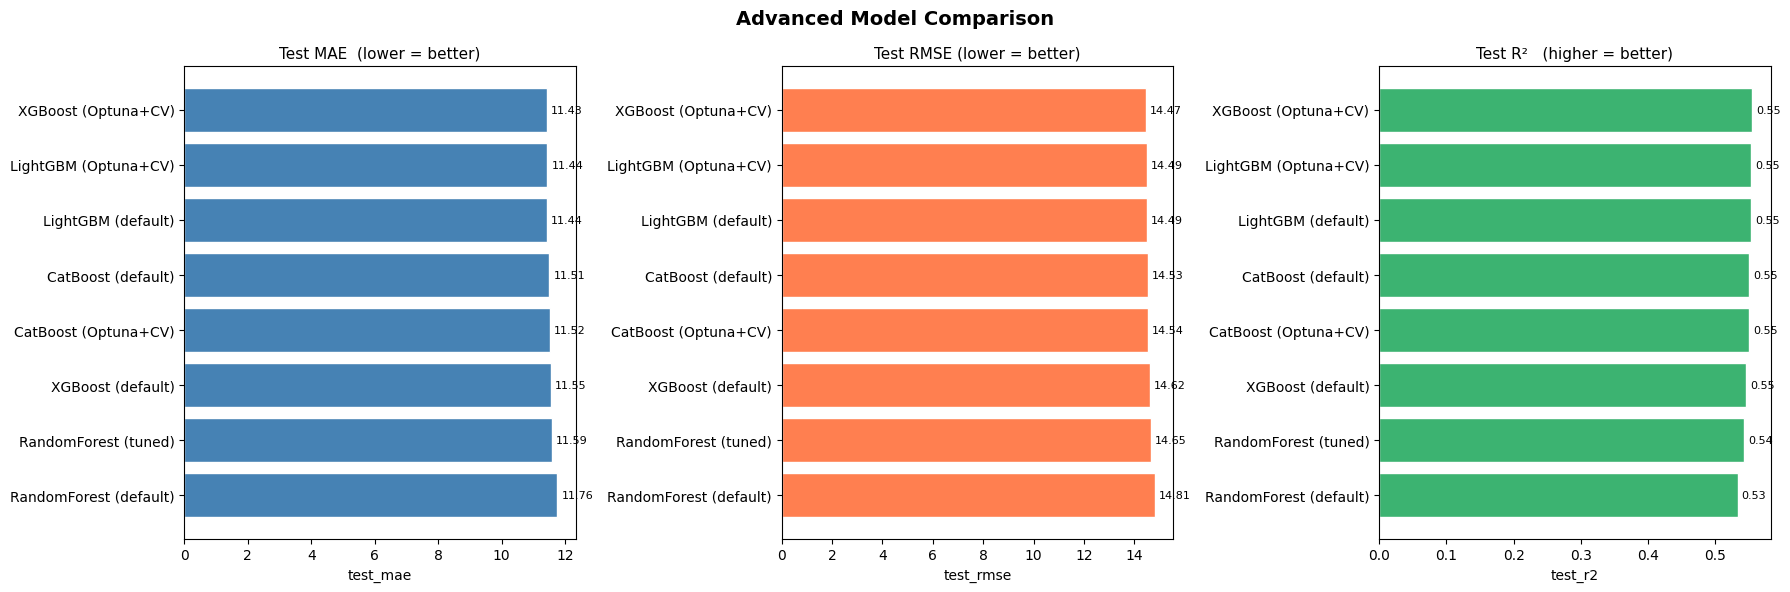

Figure saved ✓


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Advanced Model Comparison', fontsize=14, fontweight='bold')

metrics = [
    ('test_mae',  'Test MAE  (lower = better)',  'steelblue'),
    ('test_rmse', 'Test RMSE (lower = better)', 'coral'),
    ('test_r2',   'Test R²   (higher = better)', 'mediumseagreen'),
]

for ax, (col, title, color) in zip(axes, metrics):
    bars = ax.barh(results_df['model'], results_df[col], color=color, edgecolor='white')
    ax.set_title(title, fontsize=11)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.set_xlabel(col)
    ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIGURE_DIR / 'advanced_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figure saved ✓')

In [ ]:
best_row = results_df.iloc[0]
best_name = best_row['model']
print(f'Best advanced model : {best_name}')
print(f'Test RMSE    : {best_row["test_rmse"]:.2f}')
print(f'Test R2      : {best_row["test_r2"]:.2f}')
print(f'Test MAE     : {best_row["test_mae"]:.2f}')
print(f'Overfit gap  : {best_row["overfit_gap"]:.2f}')

model_map = {
    'RandomForest (default)'  : rf_default,
    'RandomForest (tuned)'    : best_rf,
    'XGBoost (default)'       : xgb_default,
    'XGBoost (Optuna+CV)'     : best_xgb,
    'LightGBM (default)'      : lgb_default,
    'LightGBM (Optuna+CV)'    : best_lgb,
    'CatBoost (default)'      : cat_default,
    'CatBoost (Optuna+CV)'    : best_cat,
}
best_model = model_map[best_name]

joblib.dump(best_model, MODEL_DIR / 'best_model_totaltime.joblib')
results_df.to_csv(MODEL_DIR / 'advanced_results_totaltime.csv', index=False)

print('\nModel saved → models/best_model_totaltime.joblib')
print('Results saved → models/advanced_results_totaltime.csv')


Best advanced model : XGBoost (Optuna+CV)
Test RMSE    : 14.47
Test R2      : 0.55
Test MAE     : 11.43
Overfit gap  : 0.13

Model saved → models/best_model_totaltime.joblib
Results saved → models/advanced_results_totaltime.csv


## Summary

| Step | Detail |
|------|--------|
| Target | `total_time_min` |
| Models | RF (RandomizedSearch), XGBoost + LightGBM + CatBoost (Optuna TPE) |
| Tuning | Optuna 50 trials / RandomizedSearchCV 30 iter |
| Output | `rf_tuned`, `xgb_tuned`, `lgb_tuned`, `cat_tuned` — all `_totaltime.joblib` |
| Best | Saved to `models/best_model_totaltime.joblib` |

Next: `03_ModelEvaluation.ipynb` — เปรียบเทียบ baseline vs advanced + feature importance